In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

import string

from transformers import BertTokenizer, BertModel, logging

In [2]:
logging.set_verbosity_error()

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

embeddings = model.embeddings.word_embeddings.weight.detach().numpy()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

# Tokenize and create the matrices

In [3]:
digitokens = np.zeros(10, dtype=int)

for i in range(10):
  tok = tokenizer.encode(str(i), add_special_tokens=False)
  print(f'Length of tokens for {i}: {len(tok)} and the token_id is: {tok}')

  digitokens[i] = tok[0]


Length of tokens for 0: 1 and the token_id is: [1014]
Length of tokens for 1: 1 and the token_id is: [1015]
Length of tokens for 2: 1 and the token_id is: [1016]
Length of tokens for 3: 1 and the token_id is: [1017]
Length of tokens for 4: 1 and the token_id is: [1018]
Length of tokens for 5: 1 and the token_id is: [1019]
Length of tokens for 6: 1 and the token_id is: [1020]
Length of tokens for 7: 1 and the token_id is: [1021]
Length of tokens for 8: 1 and the token_id is: [1022]
Length of tokens for 9: 1 and the token_id is: [1023]


In [4]:
# list of 10 EU countries
EUstates = ['estonia','france','germany','italy','latvia','lithuania','netherlands','poland','romania','slovenia' ]


# find the token index for this numer
EUtokens =np.zeros(len(EUstates), dtype=int)

for i in range(len(EUstates)):

  # confirm they're all single-token words
  toks = tokenizer.encode(EUstates[i], add_special_tokens=False)
  print(f'Length of tokens for {EUstates[i]}: {len(toks)}')

  EUtokens[i] = toks[0]

Length of tokens for estonia: 1
Length of tokens for france: 1
Length of tokens for germany: 1
Length of tokens for italy: 1
Length of tokens for latvia: 1
Length of tokens for lithuania: 1
Length of tokens for netherlands: 1
Length of tokens for poland: 1
Length of tokens for romania: 1
Length of tokens for slovenia: 1


# Embeddings for the digitokans and EUtokens

In [5]:
embeddings_digi = embeddings[digitokens]
embeddings_EU = embeddings[EUtokens]

# Mean centered submatrices

In [6]:
sub_digi = embeddings_digi# - embeddings_digi.mean(axis=0)
sub_EU = embeddings_EU# - embeddings_EU.mean(axis=0)

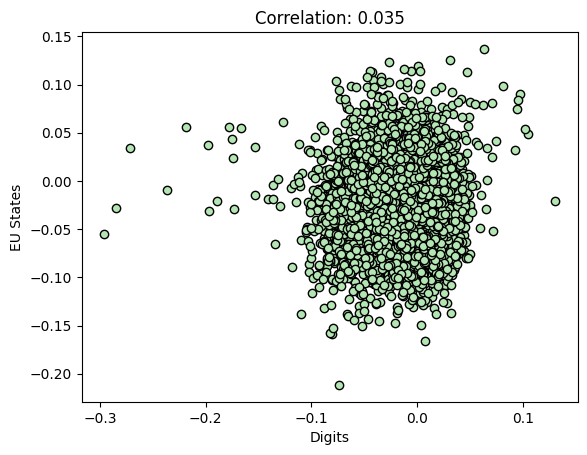

In [7]:
# Visualize
plt.scatter(sub_digi.flatten(), sub_EU.flatten(), marker='o', color=[.7,.9,.7], edgecolor='k')
plt.title(f'Correlation: {np.corrcoef(sub_EU.flatten(),sub_digi.flatten())[0,1]:.3f}')
plt.xlabel('Digits')
plt.ylabel('EU States')

plt.show()

# SVD sub-matrices for the sub matrices

In [8]:
U_digi, S_digi, V_digi = np.linalg.svd(sub_digi, full_matrices=True)
U_EU, S_EU, V_EU = np.linalg.svd(sub_EU)

print('****Shapes of the "Digi" matrices***')
print(f'U_digi: {U_digi.shape}')
print(f'S_digi: {S_digi.shape}')
print(f'V_digi: {V_digi.shape}')

print('****Shapes of the "EU" matrices***')
print(f'U_EU: {U_EU.shape}')
print(f'S_EU: {S_EU.shape}')
print(f'V_EU: {V_EU.shape}')

****Shapes of the "Digi" matrices***
U_digi: (10, 10)
S_digi: (10,)
V_digi: (768, 768)
****Shapes of the "EU" matrices***
U_EU: (10, 10)
S_EU: (10,)
V_EU: (768, 768)


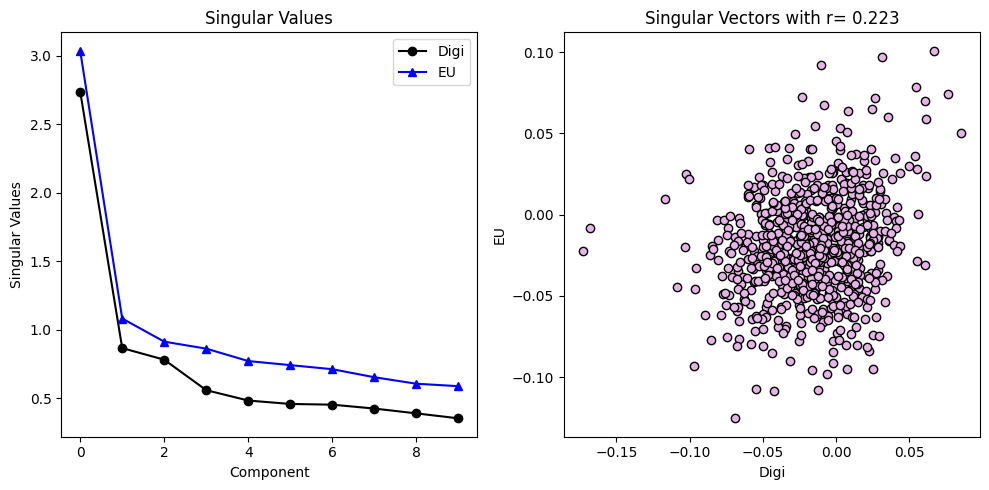

In [9]:
# Visulaize
plt.figure(figsize=(10,5))
plt.subplot(121) # 1 row, 2 columns, 1st plot
plt.plot(S_digi, 'ko-', label='Digi')
plt.plot(S_EU, 'b^-', label='EU')
plt.xlabel('Component')
plt.ylabel('Singular Values')
plt.legend()
plt.title('Singular Values')

plt.subplot(122) # 1 row, 2 columns, 2nd plot
plt.scatter(V_digi.T[0], V_EU.T[0], marker='o', color=[.9,.7,.9], edgecolor='k')
plt.title(f'Singular Vectors with r= {np.corrcoef(V_digi.T[0], V_EU.T[0])[0,1]:.3f}')
plt.xlabel('Digi')
plt.ylabel('EU')

plt.tight_layout()
plt.show()

In [47]:
# Project the mean centered matrices (mean in this case is the overall matrix mean and not individual vector means) on the first principal singular vector

proj_digi = (embeddings - embeddings_digi.mean(axis=0)[None,:]) @ V_digi[0,:]
proj_EU = (embeddings - embeddings_EU.mean(axis=0)[None,:]) @ V_EU[0,:]

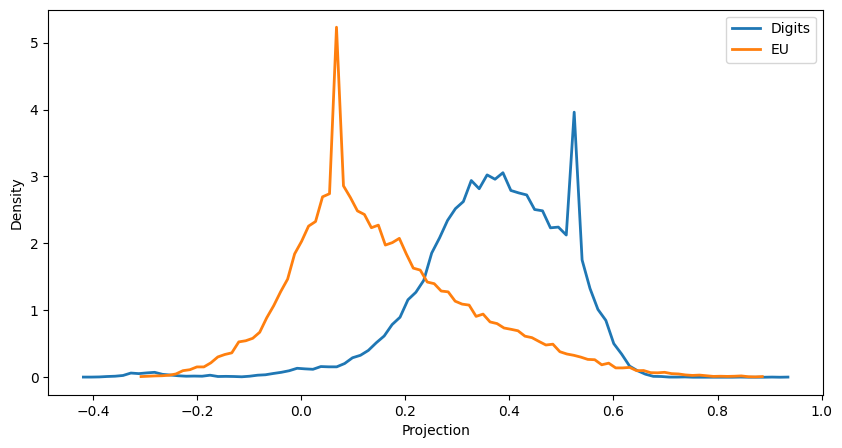

In [48]:
plt.figure(figsize=(10,5))

yD, xD = np.histogram(proj_digi, bins=90, density=True)
yE, xE = np.histogram(proj_EU, bins=90, density=True)

plt.plot(xD[:-1], yD, linewidth=2, label='Digits')
plt.plot(xE[:-1], yE, linewidth=2, label='EU')

plt.legend()
plt.xlabel('Projection')
plt.ylabel('Density')
plt.show()


In [49]:
# print top 30 projection tokens
sortidx = np.argsort(proj_EU)

# print the top positive projections
print('--- POSITIVE projections ---')
for i in range(30):

  # get this token
  token = tokenizer.decode(sortidx[-i])

  # print if it's not in the 'seed' list
  if not token in EUstates:
    print(f'  {proj_EU[sortidx[-i]]:6.3f} for "{token}"')


# repeat for top negative projections
print('\n\n\n--- NEGATIVE projections ---')
for i in range(30):

  # get this token
  token = tokenizer.decode(sortidx[i])

  # print if it's not in the 'seed' list
  if not token in EUstates:
    print(f'  {proj_EU[sortidx[i]]:6.3f} for "{token}"')

--- POSITIVE projections ---
  -0.307 for "##avs"
   0.899 for "and"
   0.897 for "in"
   0.894 for "[SEP]"
   0.891 for ","
   0.882 for "to"
   0.873 for "for"
   0.872 for "-"
   0.864 for "'"
   0.864 for """
   0.858 for "a"
   0.858 for "as"
   0.856 for "that"
   0.854 for "of"
   0.852 for "one"
   0.848 for "."
   0.847 for "by"
   0.847 for "on"
   0.845 for "or"
   0.838 for "all"
   0.838 for "at"
   0.837 for "first"
   0.836 for "from"
   0.832 for "the"
   0.830 for ":"
   0.830 for "..."
   0.828 for "with"
   0.821 for "this"
   0.820 for "his"
   0.818 for "("



--- NEGATIVE projections ---
  -0.307 for "##avs"
  -0.307 for "##omba"
  -0.298 for "690"
  -0.297 for "670"
  -0.292 for "381"
  -0.291 for "050"
  -0.288 for "##lberg"
  -0.284 for "##stov"
  -0.282 for "495"
  -0.282 for "##rdon"
  -0.280 for "##saka"
  -0.276 for "##cina"
  -0.276 for "840"
  -0.276 for "570"
  -0.272 for "##hner"
  -0.270 for "liechtenstein"
  -0.269 for "329"
  -0.268 for "##lika"
  -0

In [50]:
# repeat for numbers
sortidx = np.argsort(proj_digi)

# print the top positive projections
print('--- POSITIVE projections ---')
for i in range(30):

  # get this token
  token = tokenizer.decode(sortidx[-i])

  # print if it's not in the 'seed' list
  if not token in '0123456789':
    print(f'  {proj_digi[sortidx[-i]]:6.3f} for "{token}"')


# repeat for top negative projections
print('\n\n\n--- NEGATIVE projections ---')
for i in range(30):

  # get this token
  token = tokenizer.decode(sortidx[i])

  # print if it's not in the 'seed' list
  if not token in '0123456789':
    print(f'  {proj_digi[sortidx[i]]:6.3f} for "{token}"')

--- POSITIVE projections ---
  -0.418 for "670"
   0.950 for "[CLS]"
   0.914 for "[MASK]"
   0.853 for "[SEP]"
   0.752 for "##elial"
   0.746 for "aback"
   0.737 for "##urbed"
   0.708 for "##rricular"
   0.704 for "nedra"
   0.700 for "toward"
   0.695 for "during"
   0.695 for "kylie"
   0.694 for "sparhawk"
   0.692 for "might"
   0.687 for "glanced"
   0.685 for "་"
   0.684 for "whether"
   0.682 for "joyah"
   0.680 for "through"
   0.676 for "?"
   0.675 for "garion"
   0.672 for "onto"
   0.671 for "##gingly"
   0.670 for "seemed"
   0.669 for "abby"
   0.668 for "rearview"
   0.668 for "when"
   0.667 for "if"
   0.666 for "maybe"
   0.666 for "clary"



--- NEGATIVE projections ---
  -0.418 for "670"
  -0.389 for "840"
  -0.386 for "690"
  -0.376 for "381"
  -0.372 for "297"
  -0.369 for "930"
  -0.369 for "740"
  -0.368 for "570"
  -0.361 for "292"
  -0.356 for "354"
  -0.352 for "272"
  -0.352 for "352"
  -0.350 for "332"
  -0.348 for "385"
  -0.344 for "875"
  -0.342 fo